# Stochastic Differential Equation Safety Verification 
This notebook coordinates smooth gluing computation, Markov Chain Approximation construction, and PRISM verification.

In [1]:
import os
import re
import matplotlib.pyplot as plt
import numpy as np

from stochastic_verification import SDEConfig,PolynomialGluing, CInfinityGluing, BaseGluing, StochasticSimulator, generate_prism_ctmc_model, generate_prism_mdp_model, generate_pctl

%load_ext autoreload
%autoreload 2 

## 1. Setup

In [2]:
tau = 0.5 
sigma =1.5

# config_controlled = SDEConfig(
#     mu = lambda x,u:-x/tau+u,
#     sigma = lambda x:sigma,
#     dt=0.01, 
#     t_max=0.5, 
#     # tau=1.0, 
#     # sig=1.5, 
#     h=0.01, 
#     # alpha=2.0, 
#     # beta=2.3,
#     x_safe_min=-1.0,
#     x_safe_max=1.0,
#     epsilon=0.3,
#     x_min=-1.5, 
#     x_max=1.5,
#     x_init=-0.5,
#     U=[-1.0,1.0]
# )

config = SDEConfig(
    mu = lambda x:-x/tau,
    sigma = lambda x:sigma,
    dt=0.01, 
    t_max=0.5, 
    # tau=1.0, 
    # sig=1.5, 
    h=0.01, 
    # alpha=2.0, 
    # beta=2.3,
    x_safe_min=-1.0,
    x_safe_max=1.0,
    epsilon=0.3,
    x_min=-1.5, 
    x_max=1.5,
    x_init=-0.5
)

# mdl = model(dt=0.05, Tmax=0.5, tau=2.0, sig=1, h=0.002, alpha=0.5, beta=0.9, xmax=2.0, seed=5)


## 2. Polynomial Gluing and Error Computation

Weak Discretization Error Bound: 2.361673816186729
Smoothing Error Bound: 0.08798973178879915
Total Error : 2.449663547975528


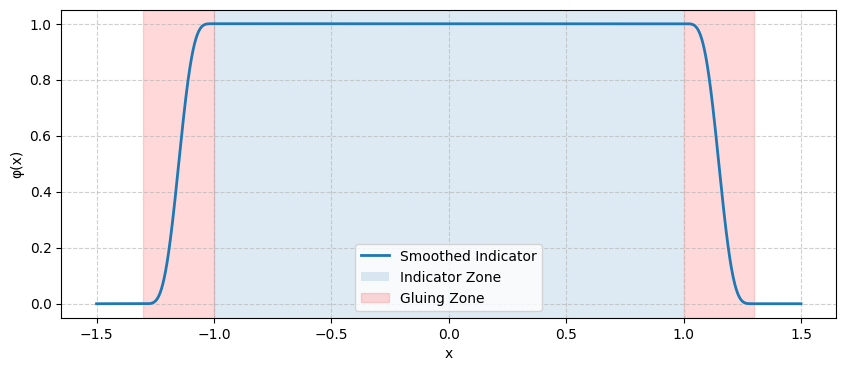

In [3]:
gluing = PolynomialGluing(config, degree=9)
gluing.plot()
# plt.show()

(weak_error_bound,smoothing_error) = gluing.compute_error_bounds()
print(f"Weak Discretization Error Bound: {weak_error_bound}")
print(f"Smoothing Error Bound: {smoothing_error}")
total_error_poly = weak_error_bound+smoothing_error
print(f"Total Error : {total_error_poly}")

## Flat Gluing and Error Computation

Weak Discretization Error Bound: 8.650986859691422
Smoothing Error Bound: 0.08798972588862825
Total Error : 8.73897658558005


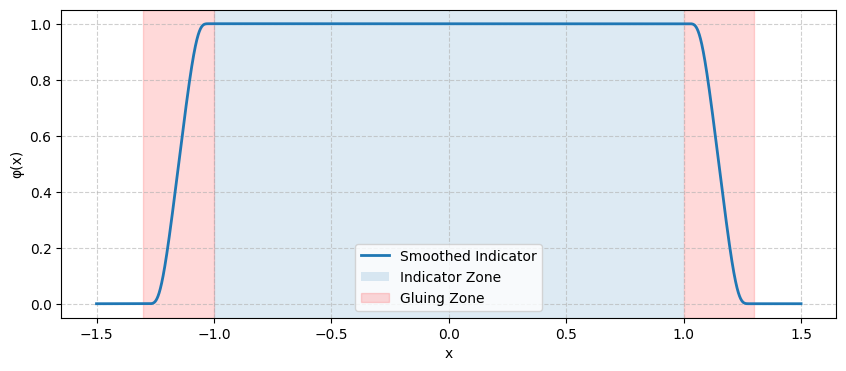

In [4]:
gluing = CInfinityGluing(config)
gluing.plot()

(weak_error_bound,smoothing_error) = gluing.compute_error_bounds()
print(f"Weak Discretization Error Bound: {weak_error_bound}")
print(f"Smoothing Error Bound: {smoothing_error}")
total_error_flat = weak_error_bound+smoothing_error
print(f"Total Error : {total_error_flat}")

total_error = min(total_error_poly,total_error_flat)


## 3. SDE vs MCA Simulation with coupled noise

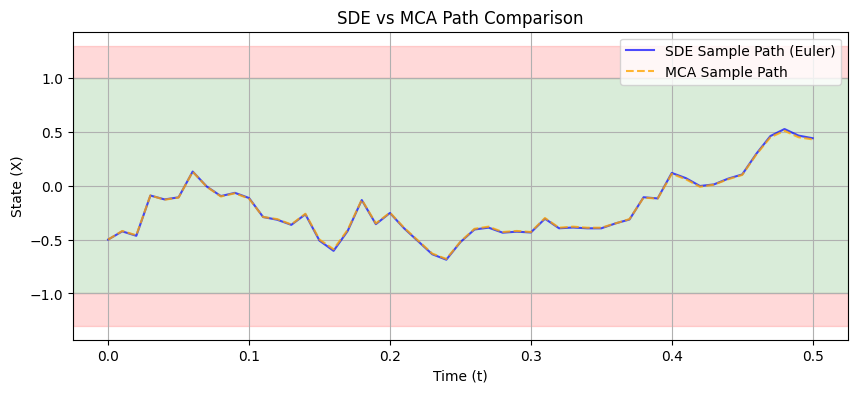

In [5]:
simulator = StochasticSimulator(config)
sim_results = simulator.run_monte_carlo(n_reps=20)
simulator.plot_one_sim(sim_results,n=0)
# Plot sample comparisons


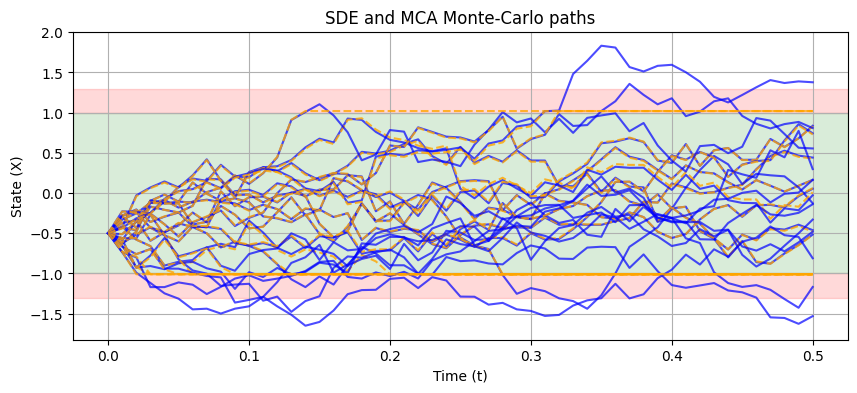

In [6]:
simulator.plot_mc_sims(sim_results)

## 4. Export to PRISM Model Checker

In [ ]:
# Write prism model and pctl properties
if config.is_controlled:
    prism_code = generate_prism_mdp_model(config,simulator)
else:
    prism_code = generate_prism_ctmc_model(config,simulator)
prism_pctl = generate_pctl(config)

with open("ou_model.sm", "w") as file:
    file.write(prism_code)

print("PRISM model structural definition file written to 'ou_model.sm'.")

with open("ou_model.pctl", "w") as file:
    file.write(prism_pctl)

print("PRISM model properties file written to 'ou_model.pctl'.")

NameError: name 'generate_prism_model' is not defined

## 5. PRISM Execution

In [ ]:
# Execute verification engine command line stream
prism_path = "/home/adrien/Tools/prism/prism-4.10-linux64-x86/bin/prism"
bash_command = f"{prism_path} ou_model.sm ou_model.pctl -exportresults res.txt"

print(f"Executing: {bash_command}")
os.system(bash_command)

Executing: /home/adrien/Tools/prism/prism-4.10-linux64-x86/bin/prism ou_model.sm ou_model.pctl -exportresults res.txt
PRISM
=====

Version: 4.10
Date: Wed Jun 10 18:19:12 CEST 2026
Hostname: latitude
Memory limits: cudd=1g, java(heap)=7.7g
Command line: prism ou_model.sm ou_model.pctl -exportresults res.txt

Parsing PRISM model file "ou_model.sm"...

Error: Syntax error ("=", line 16, column 6).


256

## 6. SDE Verification Output

In [ ]:
if os.path.exists("res.txt"):
    with open("res.txt", "r") as file:
        prism_output = file.read()
    
    results = [float(val) for val in re.findall(r"Result\s*([0-9.eE+-]+)", prism_output)]
    
    if len(results) >= 2:
        safe_prob, terminal_safe_prob = results[:2]

        # safe_prob, terminal_safe_prob, safe_prob_max = results[:2]
        print(f"PRISM : Path Continuous Safety Probability (G <= T): {safe_prob:.6f}")
        print(f"PRISM : Fixed Horizon Transient Target Probability: {terminal_safe_prob:.6f}")
        # print(f"PRISM : Maximal Safety Control Bound Trajectory: {safe_prob_max:.6f}")
        
        safe_l = max(min(safe_prob-total_error,1.0),0.0)
        safe_r = max(min(safe_prob+total_error,1.0),0.0)
        print(f"SDE : Path Continuous Safety Probability (G <= T) interval: [{safe_l:.6f},{safe_r:.6f}]")
        terminal_safe_l = max(min(terminal_safe_prob-total_error,1.0),0.0)
        terminal_safe_r = max(min(terminal_safe_prob+total_error,1.0),0.0)
        print(f"SDE : Fixed Horizon Transient Target Probability interval: [{terminal_safe_l:.6f},{terminal_safe_r:.6f}]")
        
    else:
        print("PRISM file parsing completed but unexpected metrics length encountered.")
else:
    print("Results file 'res.txt' not found. Ensure PRISM path location configurations match operational environment specifications.")

PRISM : Path Continuous Safety Probability (G <= T): 0.369922
PRISM : Fixed Horizon Transient Target Probability: 0.373051
SDE : Path Continuous Safety Probability (G <= T) interval: [0.000000,1.000000]
SDE : Fixed Horizon Transient Target Probability interval: [0.000000,1.000000]
